### PH464/564: Scientific Computing II
***J.S. Hazboun***

___

# Homework 1
### Due: Friday, Oct 3rd at 11:59pm Pacific
---

## Handing in Homework

You had the opportunity to practice your git and GitHub skills by submitting HW0 via GitHub. You will need to repeat the process for every homework assigment going forward. Please make sure a copy of the completed assignment is placed in your repos "my_work" directory and pushed to GitHub. Please label files _starting_ with the appropriate hw number. This week's will be `hw1_YOUR_NAME.ipynb`. In addition, I want another document which only has the answers to the questions asked in this HW assignment, along with any figures that you deem appropriate to make yourself understood. Please restate the question where appropriate. Code files will be checked for completeness **only**. I will only consider the answers in the separate `pdf` for grading your understanding of the questions.

**WARNING for devcontainer users:** If you are using the **devcontainer** via `VSCode`, then you will want to make a separate working folder directly in your fork of the class repo and work on your assignment by either _copying_ a notebook in there or opening a new one in that folder. The reason is that the _repo_ has the devcontainer instructions and when you open `VSCode` it recognizes this and starts up the devcontainer.  

## Problem 1



Consider a family with two children. Assume that the probability of females and males being born is equal, i.e. $p(F)=0.5$ and $p(M)=0.5$. Remember that "given" means your calculation is conditioned on some already fixed data or outcome. 

1) What is the probability of one male and one female **GIVEN** that the first child is male. 

2) What is the probability of two females **GIVEN** that at least one child is female.

3) What is the probability of two females **GIVEN** that the older child is female.

You will find it easiest to answer these questions by sketching a "tree diagram" to visualize the options for the oldest child, and the branching options for the youngest child. 

Either write your solution as Markdown/Latex below, or paste in a scanned image of your handwritten solution.

### Solution

1) *(To get you started)* If the first child is male, then the only unknown is the sex of the second child. We want the second child to be female, which has a probability of 0.5. Thus, $p(M,F |C_1=M) = 0.5$. 

2) If we know at least one child is female, then out of the four possible cases for the children (F,F; M,F; F,M; M,M), we know that the M,M case cannot be true. Out of the remaining cases, 1/3 are F,F, so $p(F,F |\text{At least one F}) = 1/3 = 0.3333$.

3) If we know the older child is female, then the only unknown is the sex of the younger child. This is a similar scenario to the first part, meaning that if we want to have two female children, the second child needs to be female rather than male, thus $p(F,F |C_1=F) = 0.5$.

## Problem 2

1) Use `numpy` to draw $1000$ random samples from a uniform distribution between $0.1$ and $10$, and store these samples as $x$.

2) Use matplotlib to make a histogram of these samples. Try to make this as aesthetically pleasing as possible (within reason).

3) Compute the base-10 log of your array $x$, and store this as $y$.

4) Make another histogram for $y$. Using the equation to transform probability distributions in `Lecture_2`, write here what the theoretical pdf of $y$ is, and overplot it onto your histogram.

5) Compute the mean of $x$ and the mean of $y$. Now compute the median of $x$ and the median of $y$. You should note that the means are different, but the medians (as it is a cumulative statistic) are the same. The mean is affected by the scale of the sample values, but the median only depends on the ordering of the samples. Monotonic transformations (like taking the log) do not change the ordering of samples.

### Solution

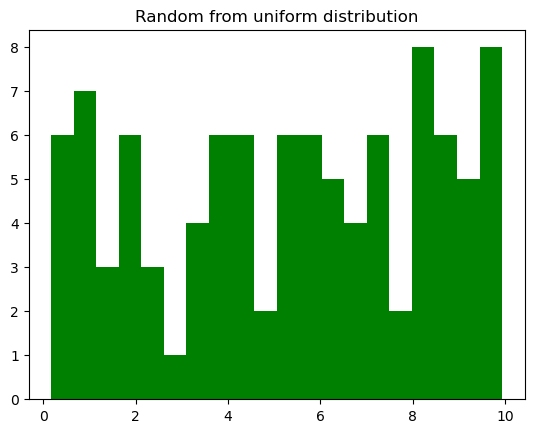

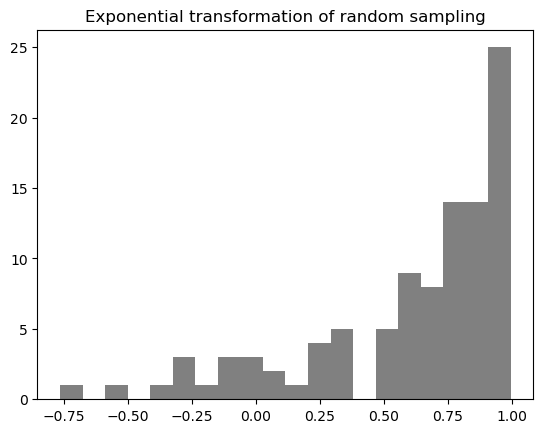

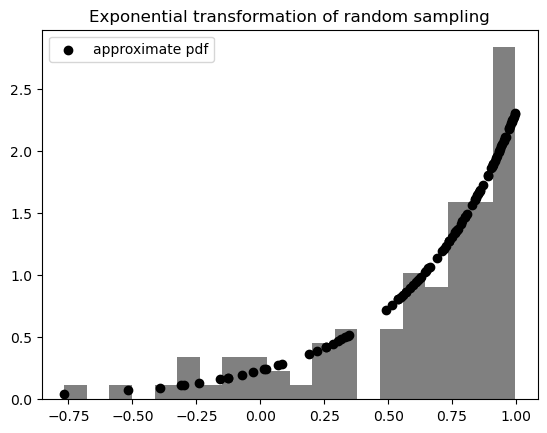

Mean of x = 5.3138937343010175
Mean of y = 0.601591366444028
Median of x = 5.54600365083717
Median of y = 0.7439490376110163
0.743980151130396


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1
x = []

for i in range(0,100):
    x.append(np.random.uniform(0.1,10))

#print(x)
 
# 2
plt.hist(x, bins=20, color='green')
plt.title("Random from uniform distribution")
plt.show()

# 3
y = np.log10(x)
#print(y)

# 4
plt.hist(y, bins=20, color='grey')
plt.title("Exponential transformation of random sampling")
plt.show()

px = 1/(10-0.1)

# Theoretical pdf of y
py = px*np.log(10)*10**y

plt.hist(y, bins=20, color='grey', density=True)
plt.scatter(y, py, label="approximate pdf", color='Black')
plt.title("Exponential transformation of random sampling")
plt.legend()
plt.show()

# 5
meanx = np.mean(x)
meany = np.mean(y)
medianx = np.median(x)
mediany = np.median(y)

print("Mean of x =", meanx)
print("Mean of y =", meany)
print("Median of x =", medianx)
print("Median of y =", mediany)
print(np.log10(medianx))
# This means the data points of medianx and mediany are the same, as we'd expect!

## Problem 3

This question is about IQ. It's a flawed and questionable metric, but useful for this problem. By definition, IQ is calibrated as a Gaussian distribution with $\mu=100$ and $\sigma=15$. 

1) Create a `scipy.stats` Gaussian object with these properties. Plot the distribution, and print out 10 random draws, along with the pdf at $x=145$. 

2) Access the `cdf` property of the Gaussian object and plot it over the same $x$-range as in (1) but in a different figure. 

3) What fraction of people have IQ > 145? *Hint: investigate all the properties of the Gaussian Python object from part (1) to find the relevant property that gives you this, or perform a calculation involving the cdf.*

4) What IQ corresponds to "one in a million"?

### Solution

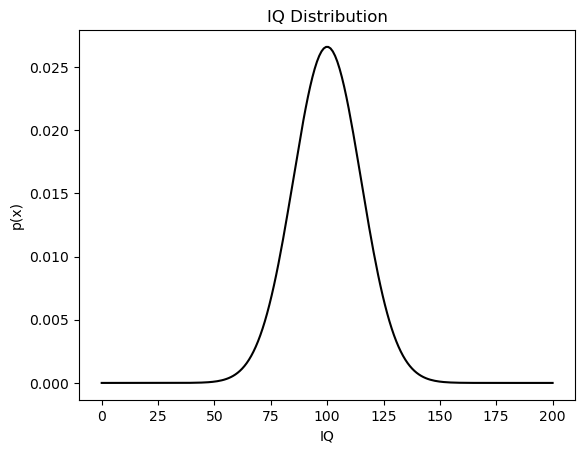

[ 89.23418532  91.146106    71.49933258  87.63945642  96.81087327
  95.16993342 117.31871094 132.02657597  88.37839639 107.05608171]
pdf at x = 145 is 0.0002954565607958672


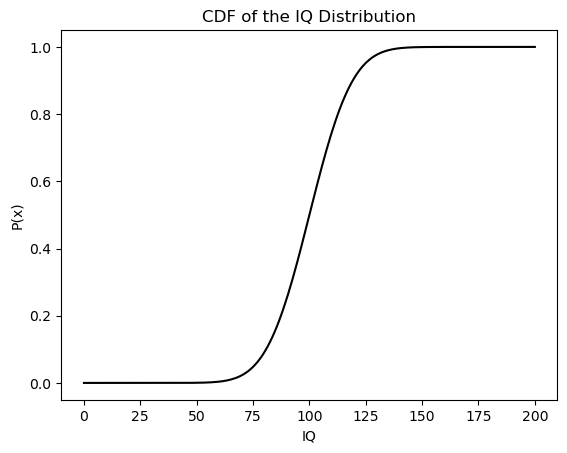

0.0013498980316301035 is the fraction of people with IQ > 145, or 0.13498980316301035 %
One in a million IQ is 172


In [15]:
from scipy.stats import norm
import math

# 1
mu = 100
sigma = 15

x = np.linspace(0, 200, 200)
IQ = norm(loc=mu, scale=sigma)

plt.plot(x, IQ.pdf(x), color='Black')
plt.xlabel("IQ")
plt.ylabel("p(x)")
plt.title("IQ Distribution")
plt.show()

rands = IQ.rvs(10)

print(rands)

print("pdf at x = 145 is", IQ.pdf(145))

# 2                 
plt.plot(x, IQ.cdf(x), color='Black')
plt.xlabel("IQ")
plt.ylabel("P(x)")
plt.title("CDF of the IQ Distribution")
plt.show()

# 3
print(1 - IQ.cdf(145), "is the fraction of people with IQ > 145, or", 
      100*(1 - IQ.cdf(145)), "%")

# 4
found = False
n = 100
while found == False:
    if (1 - IQ.cdf(n)) < 0.000001:
        found = True
    else:
        n += 1

print("One in a million IQ is", n)